17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000, Test samples: 25000
Classes: [0 1]  (0=Negative, 1=Positive)
Input shape after padding: (25000, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 94s 260ms/step - accuracy: 0.5548 - loss: 0.6819 - val_accuracy: 0.6240 - val_loss: 0.6627
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 89s 252ms/step - accuracy: 0.6132 - loss: 0.6439 - val_accuracy: 0.7860 - val_loss: 0.5381
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 141s 250ms/step - accuracy: 0.8584 - loss: 0.3498 - val_accuracy: 0.8644 - val_loss: 0.3417
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 90s 255ms/step - accuracy: 0.9252 - loss: 0.2064 - val_accuracy: 0.8704 - val_loss: 0.3472
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 90s 254ms/step - accuracy: 0.9580 - loss: 0.1333 - val_accuracy: 0.8628 - val_loss: 0.3874

Test Accuracy: 84.81%
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85     12500
    Positive       0.85      0.85      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.

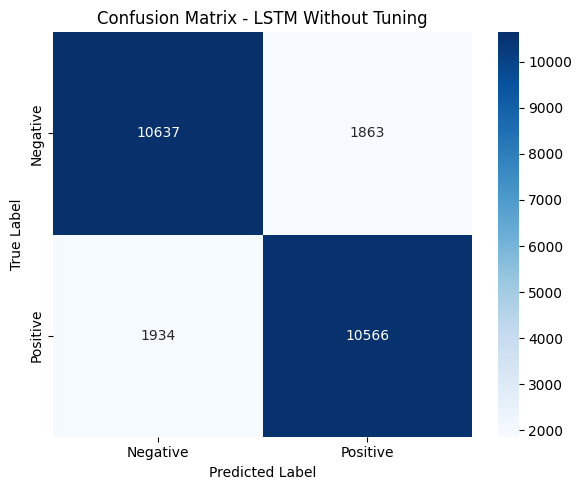

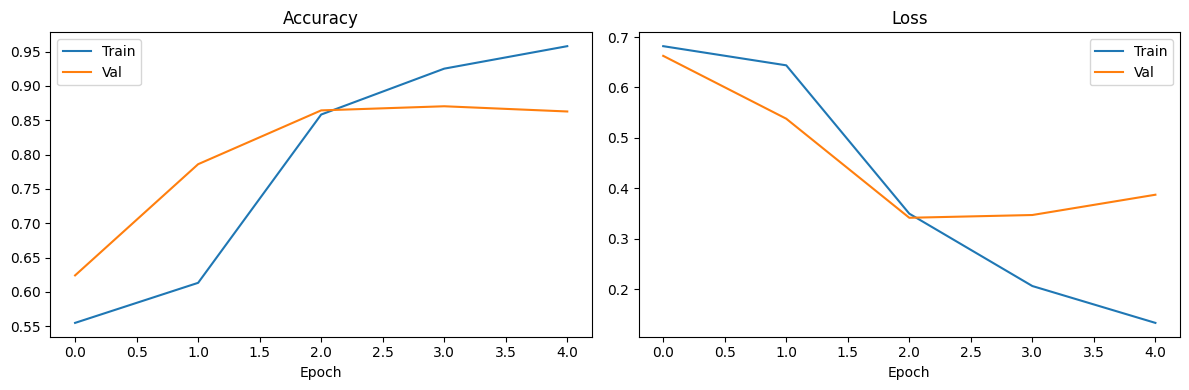

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

NUM_WORDS = 10000   # vocabulary size
MAXLEN    = 200     # max review length (words)

# Load IMDB
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=NUM_WORDS)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Classes: {np.unique(y_train)}  (0=Negative, 1=Positive)")

# Pad/truncate sequences to uniform length
X_train = pad_sequences(X_train, maxlen=MAXLEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAXLEN, padding='post', truncating='post')

print(f"Input shape after padding: {X_train.shape}")

# Build LSTM model
model = keras.Sequential([
    layers.Embedding(NUM_WORDS, 128, input_length=MAXLEN),
    layers.LSTM(64),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train
history = model.fit(X_train, y_train, epochs=5, batch_size=64,
                    validation_split=0.1, verbose=1)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title('Confusion Matrix - LSTM Without Tuning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout()
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Starting hyperparameter search (10 trials)...

Best Hyperparameters:
  embed_dim     : 128
  lstm_units    : 32
  dropout       : 0.30000000000000004
  learning_rate : 0.01
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 53s 142ms/step - accuracy: 0.6623 - loss: 0.5827 - val_accuracy: 0.8204 - val_loss: 0.4250
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 141ms/step - accuracy: 0.8551 - loss: 0.3497 - val_accuracy: 0.8476 - val_loss: 0.3651
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 48s 137ms/step - accuracy: 0.8965 - loss: 0.2614 - val_accuracy: 0.8380 - val_loss: 0.3896
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 141ms/step - accuracy: 0.9174 - loss: 0.2122 - val_accuracy: 0.8452 - val_loss: 0.4032

Stopped at epoch: 4
Test Accuracy: 82.98%
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.86      0.83     12500
    Positive       0.85      0.80      0.82     12500

    accuracy                 

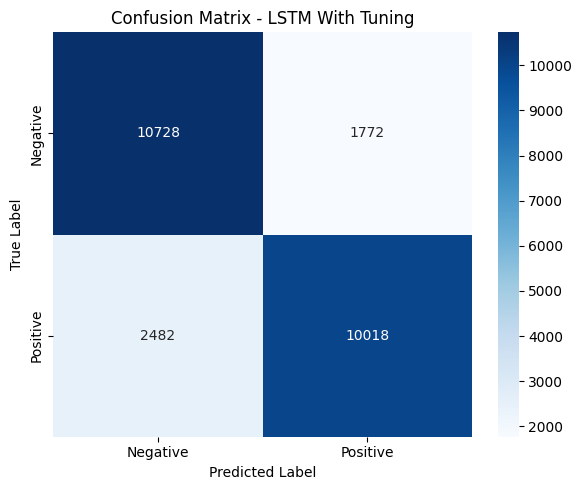

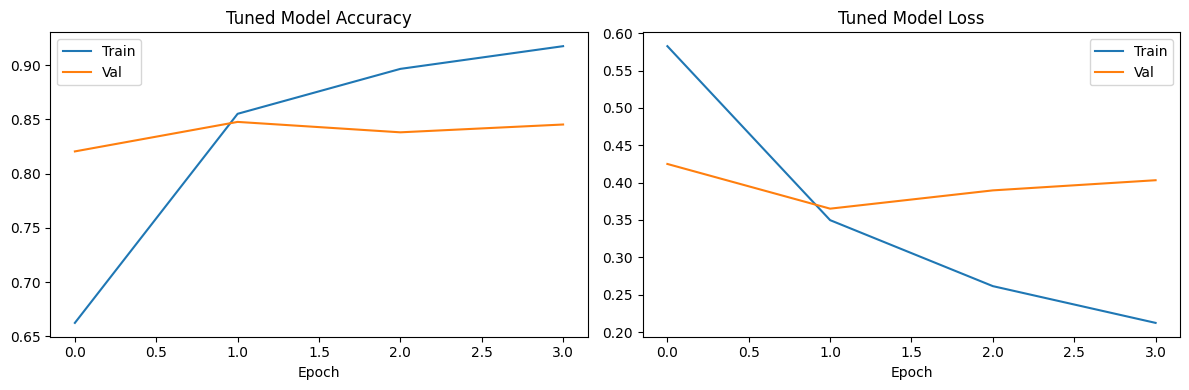

In [2]:
!pip install keras-tuner -q

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
import keras_tuner as kt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

NUM_WORDS = 10000
MAXLEN    = 200

(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=NUM_WORDS)
X_train = pad_sequences(X_train, maxlen=MAXLEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAXLEN, padding='post', truncating='post')

# Subset for faster search
X_tune = X_train[:5000]
y_tune = y_train[:5000]

def build_model(hp):
    embed_dim  = hp.Choice('embed_dim',  [64, 128])
    lstm_units = hp.Choice('lstm_units', [32, 64, 128])
    dropout    = hp.Float('dropout', 0.2, 0.4, step=0.1)
    lr         = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])

    model = keras.Sequential([
        layers.Embedding(NUM_WORDS, embed_dim, input_length=MAXLEN),
        layers.LSTM(lstm_units, dropout=dropout),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    seed=42,
    directory='lstm_tuning',
    project_name='imdb_lstm'
)

print("Starting hyperparameter search (10 trials)...")
tuner.search(X_tune, y_tune, epochs=3, validation_split=0.2, verbose=0)

best_hps = tuner.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters:")
print(f"  embed_dim     : {best_hps.get('embed_dim')}")
print(f"  lstm_units    : {best_hps.get('lstm_units')}")
print(f"  dropout       : {best_hps.get('dropout')}")
print(f"  learning_rate : {best_hps.get('learning_rate')}")

# Train best model on full data
best_model = tuner.hypermodel.build(best_hps)
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2,
                                            restore_best_weights=True)
history = best_model.fit(X_train, y_train, epochs=10, batch_size=64,
                         validation_split=0.1, callbacks=[early_stop], verbose=1)

print(f"\nStopped at epoch: {len(history.history['accuracy'])}")

test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred = (best_model.predict(X_test) > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title('Confusion Matrix - LSTM With Tuning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Tuned Model Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Tuned Model Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout()
plt.show()
